In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("../database/air_quality.db")

In [4]:
query = "SELECT * FROM air_quality"

df = pd.read_sql_query(query, conn)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         39 non-null     int64  
 1   timestamp  39 non-null     object 
 2   aqi        39 non-null     int64  
 3   pm2_5      39 non-null     float64
 4   pm10       39 non-null     float64
 5   co         39 non-null     float64
 6   no2        39 non-null     float64
 7   o3         39 non-null     float64
 8   so2        39 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.9+ KB


In [6]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,20.000000,3.230769,42.624615,46.749231,709.893333,17.171795,43.847436,6.206923
std,11.401754,0.536143,13.914056,15.056364,92.690529,5.748900,36.172502,1.268466
min,1.000000,3.000000,29.790000,33.350000,508.770000,3.620000,7.390000,4.860000
25%,10.500000,3.000000,33.680000,37.130000,662.985000,15.760000,17.380000,5.190000
50%,20.000000,3.000000,37.820000,40.430000,730.480000,17.160000,31.830000,5.730000
75%,29.500000,3.000000,43.250000,49.875000,790.120000,20.380000,55.600000,7.060000
max,39.000000,5.000000,80.250000,88.380000,839.800000,25.680000,134.230000,9.470000


In [7]:
df.isnull().sum()

id           0
timestamp    0
aqi          0
pm2_5        0
pm10         0
co           0
no2          0
o3           0
so2          0
dtype: int64

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.isnull().sum()

id           0
timestamp    0
aqi          0
pm2_5        0
pm10         0
co           0
no2          0
o3           0
so2          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.dtypes

id                    int64
timestamp    datetime64[ns]
aqi                   int64
pm2_5               float64
pm10                float64
co                  float64
no2                 float64
o3                  float64
so2                 float64
dtype: object

In [15]:
#feature engineering
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["weekday"] = df["timestamp"].dt.day_name()
df.tail()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
34,35,2026-07-20 03:04:33,3,39.19,40.83,827.76,25.41,7.39,4.86,3,20,Monday
35,36,2026-07-20 12:35:26,3,34.99,38.90,797.93,18.72,15.35,7.09,12,20,Monday
36,37,2026-07-20 13:03:47,3,34.99,38.90,797.93,18.72,15.35,7.09,13,20,Monday
37,38,2026-07-20 14:03:43,3,33.70,37.45,797.21,19.71,17.45,6.97,14,20,Monday
38,39,2026-07-20 15:03:43,3,32.50,36.22,797.51,20.41,18.72,7.03,15,20,Monday


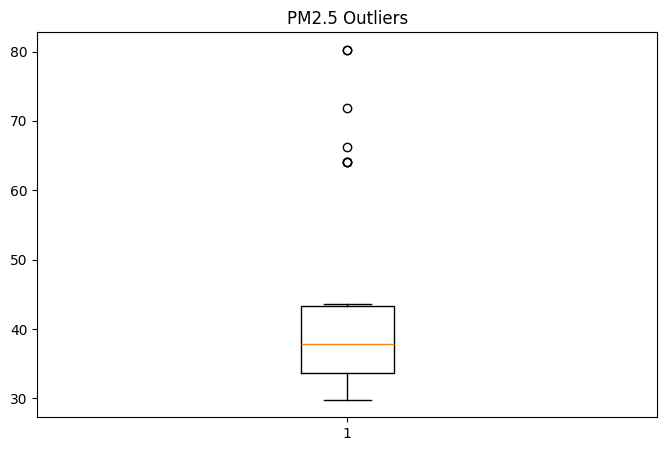

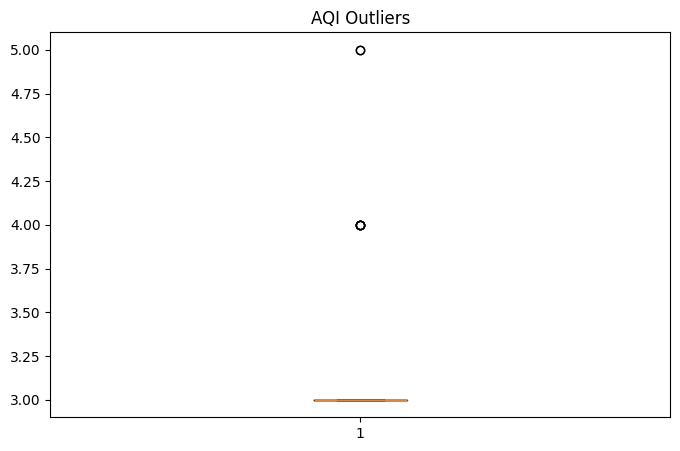

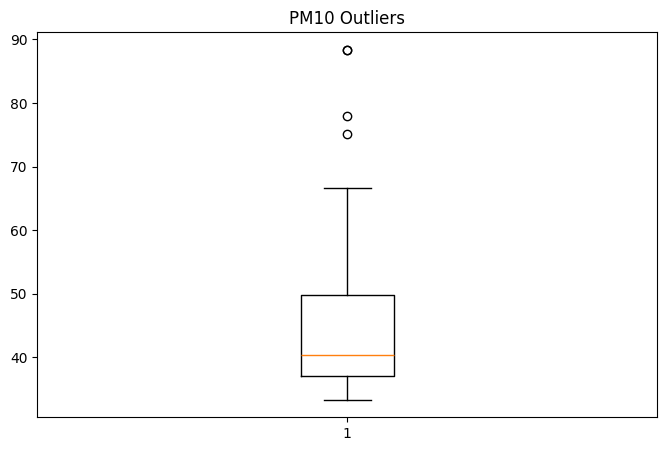

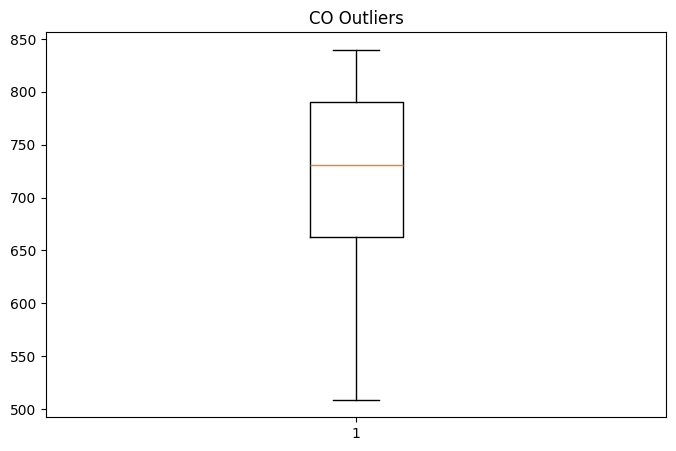

In [19]:
#checking for outliers using boxplots
plt.figure(figsize=(8,5))
plt.boxplot(df["pm2_5"])
plt.title("PM2.5 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["aqi"])
plt.title("AQI Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["pm10"])
plt.title("PM10 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["co"])
plt.title("CO Outliers")
plt.show()



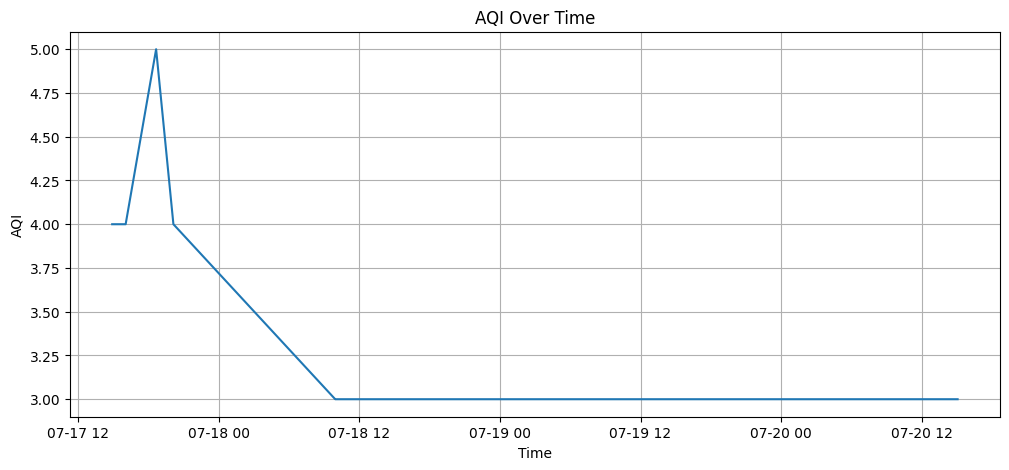

In [20]:
#aqi trend
plt.figure(figsize=(12,5))

plt.plot(df["timestamp"], df["aqi"])

plt.xlabel("Time")

plt.ylabel("AQI")

plt.title("AQI Over Time")

plt.grid(True)

plt.show()

In [21]:
#correlation matrix
corr = df.corr(numeric_only=True)
corr

,id,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day
id,1.000000,-0.606992,-0.717647,-0.727301,0.574818,0.683032,-0.854400,-0.133628,-0.196904,0.962040
aqi,-0.606992,1.000000,0.944621,0.931922,-0.308463,-0.426521,0.744877,0.075366,0.180118,-0.664972
pm2_5,-0.717647,0.944621,1.000000,0.992046,-0.318258,-0.473475,0.849421,0.146324,0.077834,-0.750708
pm10,-0.727301,0.931922,0.992046,1.000000,-0.249679,-0.413602,0.822455,0.244749,0.110680,-0.767061
co,0.574818,-0.308463,-0.318258,-0.249679,1.000000,0.913571,-0.663462,0.438696,-0.207771,0.521768
no2,0.683032,-0.426521,-0.473475,-0.413602,0.913571,1.000000,-0.790665,0.331042,-0.166593,0.629205
o3,-0.854400,0.744877,0.849421,0.822455,-0.663462,-0.790665,1.000000,0.046659,0.185137,-0.864714
so2,-0.133628,0.075366,0.146324,0.244749,0.438696,0.331042,0.046659,1.000000,0.168474,-0.183613
hour,-0.196904,0.180118,0.077834,0.110680,-0.207771,-0.166593,0.185137,0.168474,1.000000,-0.413126
day,0.962040,-0.664972,-0.750708,-0.767061,0.521768,0.629205,-0.864714,-0.183613,-0.413126,1.000000


In [22]:
df.to_csv("../data/processed_air_quality.csv",index=False)

In [23]:
df.to_sql(
    "processed_air_quality",
    conn,
    if_exists="replace",
    index=False
)

39

In [24]:
conn.close()